In [36]:
# within session decoding
# mean_E, correlation
# comp. of 'select'/100/250 voxels
# n1/n2_evidence_sd
# motion (framewise displacement)

import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import pingouin
import matplotlib.pyplot as plt

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [187]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)
df.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/all_behavior_df.csv')
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


In [ ]:
pred = []
for (sub, session, n_voxels) in product(subjects, sessions,n_voxels_s):
    #print(sub, session)
    pred.append(get_decoding_info(sub, session,bids_folder=bids_folder, n_voxels=n_voxels))

temp = pred.join(df, how='inner')
temp = temp.drop('session', axis=1)
temp

# save Es ('select' method) for comparison with across session decoding: stress-decoding_effect.ipynb
temp.xs('select',0,'n_voxels').droplevel(axis=0, level=['mask','run'])[['E','sd']].to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')

In [178]:
temp

E        sd        rt  \
subject trial_nr session mask  n_voxels run                                 
1       1        1       NPC_R 100      1    3.200873  0.155523  0.476974   
                                        1    3.200873  0.155523  1.843622   
                               250      1    2.505134  0.683273  0.476974   
                                        1    2.505134  0.683273  1.843622   
                               select   1    2.659253  0.204591  0.476974   
...                                               ...       ...       ...   
61      120      2       NPC_R 100      6    2.078880  0.401937  0.989251   
                               250      6    1.867917  0.058799  2.106819   
                                        6    1.867917  0.058799  0.989251   
                               select   6    4.440225  0.185782  2.106819   
                                        6    4.440225  0.185782  0.989251   

                                               n1    n2  prob1  prob2  choice  \
subject trial_nr session mask  n_voxels run                                     
1       1        1       NPC_R 100      1    13.0  10.0   0.55   1.00    True   
                                        1    28.0  32.0   1.00   0.55   False   
                               250      1    13.0  10.0   0.55   1.00    True   
                                        1    28.0  32.0   1.00   0.55   False   
                               select   1    13.0  10.0   0.55   1.00    True   
...                                           ...   ...    ...    ...     ...   
61      120      2       NPC_R 100      6    42.0  28.0   0.55   1.00    True   
                               250      6     7.0  15.0   1.00   0.55    True   
                                        6    42.0  28.0   0.55   1.00    True   
                               select   6     7.0  15.0   1.00   0.55    True   
                                        6    42.0  28.0   0.55   1.00    True   

                                             risky_first  chose_risky  \
subject trial_nr session mask  n_voxels run                             
1       1        1       NPC_R 100      1           True        False   
                                        1          False        False   
                               250      1           True        False   
                                        1          False        False   
                               select   1           True        False   
...                                                  ...          ...   
61      120      2       NPC_R 100      6           True        False   
                               250      6          False         True   
                                        6           True        False   
                               select   6          False         True   
                                        6           True        False   

                                             n_risky  n_safe      frac  \
subject trial_nr session mask  n_voxels run                              
1       1        1       NPC_R 100      1       13.0    10.0  1.300000   
                                        1       32.0    28.0  1.142857   
                               250      1       13.0    10.0  1.300000   
                                        1       32.0    28.0  1.142857   
                               select   1       13.0    10.0  1.300000   
...                                              ...     ...       ...   
61      120      2       NPC_R 100      6       42.0    28.0  1.500000   
                               250      6       15.0     7.0  2.142857   
                                        6       42.0    28.0  1.500000   
                               select   6       15.0     7.0  2.142857   
                                        6       42.0    28.0  1.500000   

                                             log(risky/safe)   log(n1)  \
subject t

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.050293,1,47,0.050293,2.980189,0.090858,0.059627,NaN
1,session,0.004184,1,47,0.004184,1.200345,0.278835,0.024903,1.0
2,Interaction,0.002183,1,47,0.002183,0.626316,0.432686,0.013151,NaN


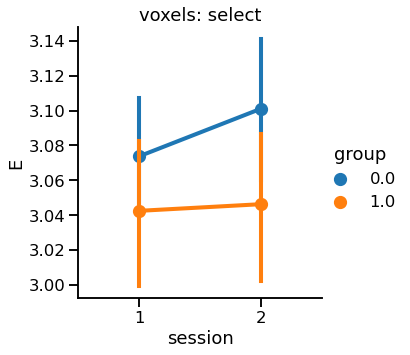

In [159]:
# mean_E
import seaborn as sns

n_voxels =  'select' #'select' #'select', 100
temp_ = temp.xs(n_voxels, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'

mean_E = temp_.groupby(['subject', 'group', 'session'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='session', hue='group', y='E',kind='point')
plt.title(f'voxels: {n_voxels}')

# looking at 'risky_first'
#mean_E = temp_.groupby(['subject', 'group', 'session', 'risky_first'])[['E']].mean()
#f = sns.catplot(data=mean_E.reset_index(), hue='group',col = 'risky_first', x='session', y='E',kind='point',errorbar = 'se')

#mean_E = mean_E.xs(1, 0, 'session') # only onse session, hue=risky_first
#f = sns.catplot(data=mean_E.reset_index(), x='group',hue = 'risky_first',  y='E',kind='point',errorbar = 'se', palette=sns.color_palette()[4:])

pingouin.mixed_anova(data=mean_E.reset_index(),dv='E', between='group', within='session', subject='subject') #


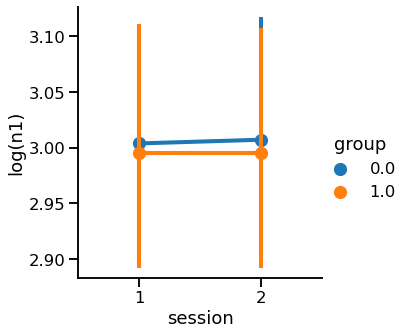

In [134]:
# objective true mean n1
mean_n1 = temp_.groupby(['subject', 'group', 'session','risky_first'])[['log(n1)']].mean()
sns.catplot(data=mean_n1.reset_index(), x='session', hue='group', y='log(n1)',kind='point') #,col = 'risky_first'

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.035385,1,47,0.035385,1.272047,0.265108,0.026352,NaN
1,session,0.007124,1,47,0.007124,0.651418,0.423672,0.013670,1.0
2,Interaction,0.010445,1,47,0.010445,0.955051,0.333440,0.019916,NaN


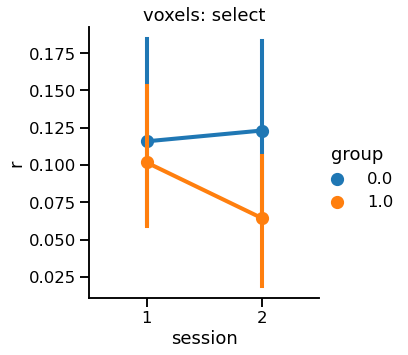

In [137]:
# correlation of true with estimate
r = temp_.groupby(['subject', 'group', 'session']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
sns.catplot(data=r.reset_index(), x='session', hue='group', y='r',kind='point',errorbar = 'se')
plt.title(f'voxels: {n_voxels}')

pingouin.mixed_anova(data=r.reset_index(),dv='r', between='group', within='session', subject='subject')


In [186]:
r.loc[r['r']== r['r'].max()]

,,n,r,CI95%,p-val,BF10,power
subject,session,,,,,,
59,1,240,0.503932,"[0.4, 0.59]",7.332053e-17,8.371e+13,1.0


Text(0.5, 1.0, 'voxels: 250 \n r=-0.12, p= 0.4108')

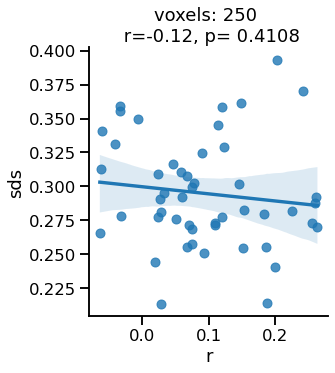

In [43]:
# correlation of SDS(E) and r(corr true log-n with E)
n_voxels =  250 #'select', 100
temp_ = temp.xs(n_voxels, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'

r = temp_.groupby(['subject']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r = r.droplevel(axis=0, level=1)
sds = temp_.groupby(['subject']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')

t = sds.join(r['r'])
sns.lmplot(x='r',y='sds', data=t, )
cor = pingouin.corr(t['r'], t['sds'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'voxels: {n_voxels} \n r={r_}, p= {p}')


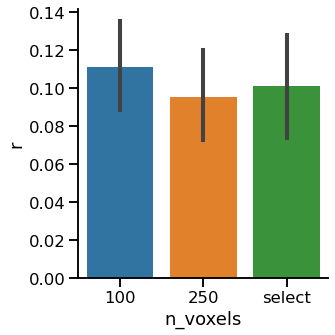

In [28]:
# comparison between different voxel-selections
import seaborn as sns
sns.set_context('talk')
t =  temp.groupby(['subject', 'n_voxels', 'session', 'group']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
sns.catplot(data=t.reset_index(), x='n_voxels', y='r', kind='bar')# , col='session', row='group'

#sns.catplot(data=r, x='group', y='r', kind='bar')


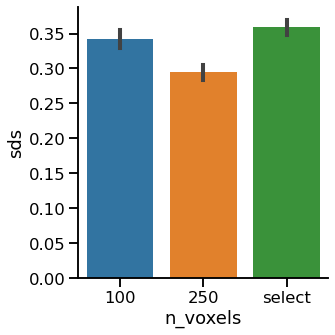

In [151]:
t =  temp.groupby(['subject', 'n_voxels']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')
sns.catplot(data=t.reset_index(), x='n_voxels', y='sds', kind='bar')# , col='session', row='group'


In [86]:
df_n1_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv').set_index(['subject','session'])
df_n2_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n2_evidence_sd.csv').set_index(['subject','session'])


In [139]:
n_voxels =  'select' #'select', 100
temp_ = temp.xs(n_voxels, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'
r = temp_.groupby(['subject', 'session']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r = r.droplevel(axis=0, level=2)
sds = temp_.groupby(['subject', 'session']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')

Text(0.5, 1.0, 'voxels: select \n r=0.03, p= 0.85615')

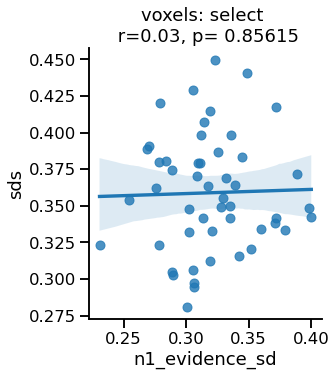

In [148]:
n= 1
t = df_n1_ev_sd.join(r[['r']]).join(sds)

t= t.groupby(['subject']).mean()
var2 = 'sds' # 'r'
sns.lmplot(x=f'n{n}_evidence_sd',y=var2, data=t, )
cor = pingouin.corr(t[f'n{n}_evidence_sd'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'voxels: {n_voxels} \n r={r_}, p= {p}')

In [181]:
df_motion = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_motion.csv').set_index(['subject', 'session'])

#df_motion = df_motion.join(r[['r']]).join(sds).join(group_mapping).set_index('group', append=True)


In [182]:
df_motion

,,motion
subject,session,
1,1,0.136455
2,1,0.078612
3,1,0.227647
4,1,0.175592
5,1,0.129649
...,...,...
55,2,0.083996
57,2,0.076428
58,2,0.126233


In [80]:
df_motion

,,,motion,r,sds
subject,session,group,,,
1,1,0.0,0.136455,0.038720,0.297518
2,1,0.0,0.078612,-0.020357,0.362907
3,1,1.0,0.227647,0.046211,0.321081
4,1,1.0,0.175592,0.113527,0.434422
5,1,0.0,0.129649,0.242084,0.357107
...,...,...,...,...,...
55,2,0.0,0.083996,0.203376,0.252919
57,2,1.0,0.076428,0.187939,0.311412
58,2,1.0,0.126233,0.264077,0.374376


Text(0.5, 1.0, 'voxels: select \n r=0.22, p= 0.12723')

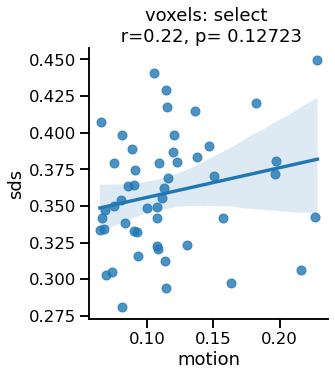

In [144]:
var2 = 'sds' # 'r'
t = df_motion
t= t.groupby(['subject']).mean()

sns.lmplot(x='motion',y=var2, data=t.reset_index()) #,col='session',row='group' 
cor = pingouin.corr(t['motion'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'voxels: {n_voxels} \n r={r_}, p= {p}')


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.000328,1,48,0.000328,0.088443,0.767450,0.001839,NaN
1,session,0.002689,1,48,0.002689,5.511375,0.023064,0.102994,1.0
2,Interaction,0.000043,1,48,0.000043,0.087315,0.768894,0.001816,NaN


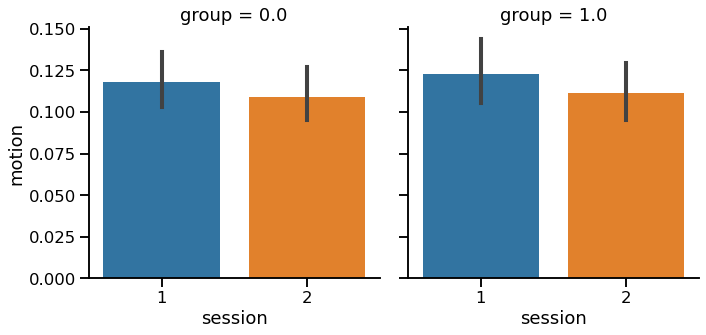

In [85]:
sns.catplot(data=t.reset_index(), x='session', y='motion', kind='bar', col='group')
pingouin.mixed_anova(data=t.reset_index(),dv='motion', between='group', within='session', subject='subject')